# 📦 Case Study 5 — Inventory Valuation: FIFO vs LIFO vs Weighted Average

**SDNB Vaishnav College for Women — Accounting Capstone**

---

## 🏢 Background

You are the **Junior Accountant** at **Bharath Cotton Mills**, Coimbatore. The company sells one fast-moving SKU — *Cotton Saree* — and books all transactions in a single inventory ledger.

The Senior Manager — Costing wants to **switch the company's inventory valuation method** for FY 2026-27. Right now they use FIFO, but raw-cotton prices have been rising and management wants to know whether **LIFO** or **Weighted Average** would produce a better tax position.

> *"Take Q1 actuals (Jan-Apr 2026). Apply all three methods. Show me the impact on COGS, gross profit, ending inventory, and tax. Then make a recommendation."*

## 📋 The three methods

| Method | Cost flow assumption | Effect when prices rising |
|--------|----------------------|---------------------------|
| **FIFO** (First-In, First-Out) | Oldest stock sold first | Lower COGS, higher profit, higher tax, higher ending inventory |
| **LIFO** (Last-In, First-Out) | Newest stock sold first | Higher COGS, lower profit, lower tax, lower ending inventory |
| **Weighted Average** | Each unit costed at running average | Smoothed values between FIFO & LIFO |

> **Note:** Indian Accounting Standards (Ind AS 2 / AS 2) **do not permit LIFO** — only FIFO and Weighted Average are allowed for statutory reporting. This case study still computes LIFO so students see the comparison and understand why the prohibition exists.

## 🎯 Your tasks

1. Load the inventory transactions (purchases + sales)
2. Implement each of the three valuation methods
3. Compare COGS, ending inventory, gross profit and tax under each
4. Visualise the differences
5. Recommend a method (within Ind-AS-permitted options)

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from collections import deque
import os

DATA = "data/" if os.path.isdir("data") else "case_studies/data/"

txns = pd.read_csv(DATA + "inventory_transactions.csv")
txns["Date"] = pd.to_datetime(txns["Date"])
txns["UnitPrice"] = pd.to_numeric(txns["UnitPrice"], errors="coerce")
print(f"✅ Loaded {len(txns)} transactions")
print(txns.to_string(index=False))

✅ Loaded 10 transactions
      Date     Type  Quantity  UnitPrice
2026-01-05 Purchase       500      320.0
2026-01-12 Purchase       300      340.0
2026-01-20     Sale       400        NaN
2026-02-02 Purchase       400      360.0
2026-02-15     Sale       350        NaN
2026-03-01 Purchase       600      380.0
2026-03-10 Purchase       200      400.0
2026-03-22     Sale       500        NaN
2026-04-05 Purchase       300      410.0
2026-04-18     Sale       450        NaN


In [2]:
# Sanity check — selling price assumption (uniform across the period)
SELLING_PRICE = 550.00       # ₹/saree
TAX_RATE      = 0.25         # 25% corporate tax (simplified)

total_purchases = txns[txns["Type"] == "Purchase"]
total_sales     = txns[txns["Type"] == "Sale"]

units_purchased = total_purchases["Quantity"].sum()
units_sold      = total_sales["Quantity"].sum()

print(f"Units purchased : {units_purchased}")
print(f"Units sold      : {units_sold}")
print(f"Closing units   : {units_purchased - units_sold}")
print(f"Selling price   : ₹{SELLING_PRICE}/unit")
print(f"Total revenue   : ₹{units_sold * SELLING_PRICE:,.2f}")

Units purchased : 2300
Units sold      : 1700
Closing units   : 600
Selling price   : ₹550.0/unit
Total revenue   : ₹935,000.00


## 🔹 Method 1 — FIFO (First-In, First-Out)

Use a **queue**: each new purchase joins the back of the line, each sale consumes from the front.

In [3]:
def fifo_valuation(txns):
    queue = deque()           # each entry: [qty_remaining, unit_price]
    cogs_total = 0.0
    cogs_log   = []

    for _, row in txns.iterrows():
        if row["Type"] == "Purchase":
            queue.append([row["Quantity"], row["UnitPrice"]])
        else:                                   # Sale
            qty_to_sell = row["Quantity"]
            sale_cogs   = 0.0
            while qty_to_sell > 0 and queue:
                front = queue[0]
                used  = min(qty_to_sell, front[0])
                sale_cogs   += used * front[1]
                front[0]    -= used
                qty_to_sell -= used
                if front[0] == 0:
                    queue.popleft()
            cogs_total += sale_cogs
            cogs_log.append({"Date": row["Date"], "Sold": row["Quantity"],
                             "COGS": round(sale_cogs, 2)})

    closing_units = sum(q for q, _ in queue)
    closing_value = sum(q * p for q, p in queue)
    return cogs_total, closing_units, closing_value, pd.DataFrame(cogs_log)


fifo_cogs, fifo_units, fifo_value, fifo_log = fifo_valuation(txns)
print("FIFO sale-by-sale COGS:")
print(fifo_log.to_string(index=False))
print(f"\nTotal COGS (FIFO)      : ₹{fifo_cogs:,.2f}")
print(f"Closing units (FIFO)   : {fifo_units}")
print(f"Closing value (FIFO)   : ₹{fifo_value:,.2f}")

FIFO sale-by-sale COGS:
      Date  Sold     COGS
2026-01-20   400 128000.0
2026-02-15   350 117000.0
2026-03-22   500 180000.0
2026-04-18   450 171000.0

Total COGS (FIFO)      : ₹596,000.00
Closing units (FIFO)   : 600
Closing value (FIFO)   : ₹241,000.00


## 🔹 Method 2 — LIFO (Last-In, First-Out)

Use a **stack**: each new purchase pushes onto the top, each sale consumes from the top.

In [4]:
def lifo_valuation(txns):
    stack = []            # each entry: [qty_remaining, unit_price]
    cogs_total = 0.0
    cogs_log   = []

    for _, row in txns.iterrows():
        if row["Type"] == "Purchase":
            stack.append([row["Quantity"], row["UnitPrice"]])
        else:                                   # Sale
            qty_to_sell = row["Quantity"]
            sale_cogs   = 0.0
            while qty_to_sell > 0 and stack:
                top  = stack[-1]
                used = min(qty_to_sell, top[0])
                sale_cogs   += used * top[1]
                top[0]      -= used
                qty_to_sell -= used
                if top[0] == 0:
                    stack.pop()
            cogs_total += sale_cogs
            cogs_log.append({"Date": row["Date"], "Sold": row["Quantity"],
                             "COGS": round(sale_cogs, 2)})

    closing_units = sum(q for q, _ in stack)
    closing_value = sum(q * p for q, p in stack)
    return cogs_total, closing_units, closing_value, pd.DataFrame(cogs_log)


lifo_cogs, lifo_units, lifo_value, lifo_log = lifo_valuation(txns)
print("LIFO sale-by-sale COGS:")
print(lifo_log.to_string(index=False))
print(f"\nTotal COGS (LIFO)      : ₹{lifo_cogs:,.2f}")
print(f"Closing value (LIFO)   : ₹{lifo_value:,.2f}")

LIFO sale-by-sale COGS:
      Date  Sold     COGS
2026-01-20   400 134000.0
2026-02-15   350 126000.0
2026-03-22   500 194000.0
2026-04-18   450 180000.0

Total COGS (LIFO)      : ₹634,000.00
Closing value (LIFO)   : ₹203,000.00


## 🔹 Method 3 — Weighted Average (perpetual)

After every purchase, recompute the average unit cost. Each sale is costed at the **running** average.

In [5]:
def weighted_avg_valuation(txns):
    units = 0
    value = 0.0
    cogs_total = 0.0
    cogs_log   = []

    for _, row in txns.iterrows():
        if row["Type"] == "Purchase":
            units += row["Quantity"]
            value += row["Quantity"] * row["UnitPrice"]
        else:                                   # Sale
            avg_cost = value / units if units else 0
            sale_cogs = avg_cost * row["Quantity"]
            cogs_total += sale_cogs
            value -= sale_cogs
            units -= row["Quantity"]
            cogs_log.append({"Date": row["Date"], "Sold": row["Quantity"],
                             "AvgCost": round(avg_cost, 2),
                             "COGS": round(sale_cogs, 2)})

    return cogs_total, units, value, pd.DataFrame(cogs_log)


wa_cogs, wa_units, wa_value, wa_log = weighted_avg_valuation(txns)
print("Weighted-Average sale-by-sale COGS:")
print(wa_log.to_string(index=False))
print(f"\nTotal COGS (WA)        : ₹{wa_cogs:,.2f}")
print(f"Closing value (WA)     : ₹{wa_value:,.2f}")

Weighted-Average sale-by-sale COGS:
      Date  Sold  AvgCost      COGS
2026-01-20   400   327.50 131000.00
2026-02-15   350   343.75 120312.50
2026-03-22   500   370.15 185075.00
2026-04-18   450   381.54 171691.07

Total COGS (WA)        : ₹608,078.57
Closing value (WA)     : ₹228,921.43


## 🔹 Side-by-side comparison

Build the comparison table and compute downstream metrics: gross profit, tax, net profit.

In [6]:
revenue = units_sold * SELLING_PRICE

methods = ["FIFO", "LIFO", "Weighted Avg"]
cogs    = [fifo_cogs, lifo_cogs, wa_cogs]
end_inv = [fifo_value, lifo_value, wa_value]

comp = pd.DataFrame({
    "Method"            : methods,
    "Revenue"           : [revenue]*3,
    "COGS"              : cogs,
    "Gross Profit"      : [revenue - c for c in cogs],
    "Gross Margin %"    : [round((revenue - c)/revenue * 100, 2) for c in cogs],
    "Tax @25%"          : [round((revenue - c) * TAX_RATE, 2) for c in cogs],
    "Net Profit"        : [round((revenue - c) * (1 - TAX_RATE), 2) for c in cogs],
    "Ending Inventory"  : end_inv,
})
print(comp.to_string(index=False, float_format=lambda v: f"₹{v:,.0f}" if isinstance(v, float) and v >= 100 else f"{v:,.2f}"))

      Method  Revenue     COGS  Gross Profit  Gross Margin %  Tax @25%  Net Profit  Ending Inventory
        FIFO ₹935,000 ₹596,000      ₹339,000           36.26   ₹84,750    ₹254,250          ₹241,000
        LIFO ₹935,000 ₹634,000      ₹301,000           32.19   ₹75,250    ₹225,750          ₹203,000
Weighted Avg ₹935,000 ₹608,079      ₹326,921           34.96   ₹81,730    ₹245,191          ₹228,921


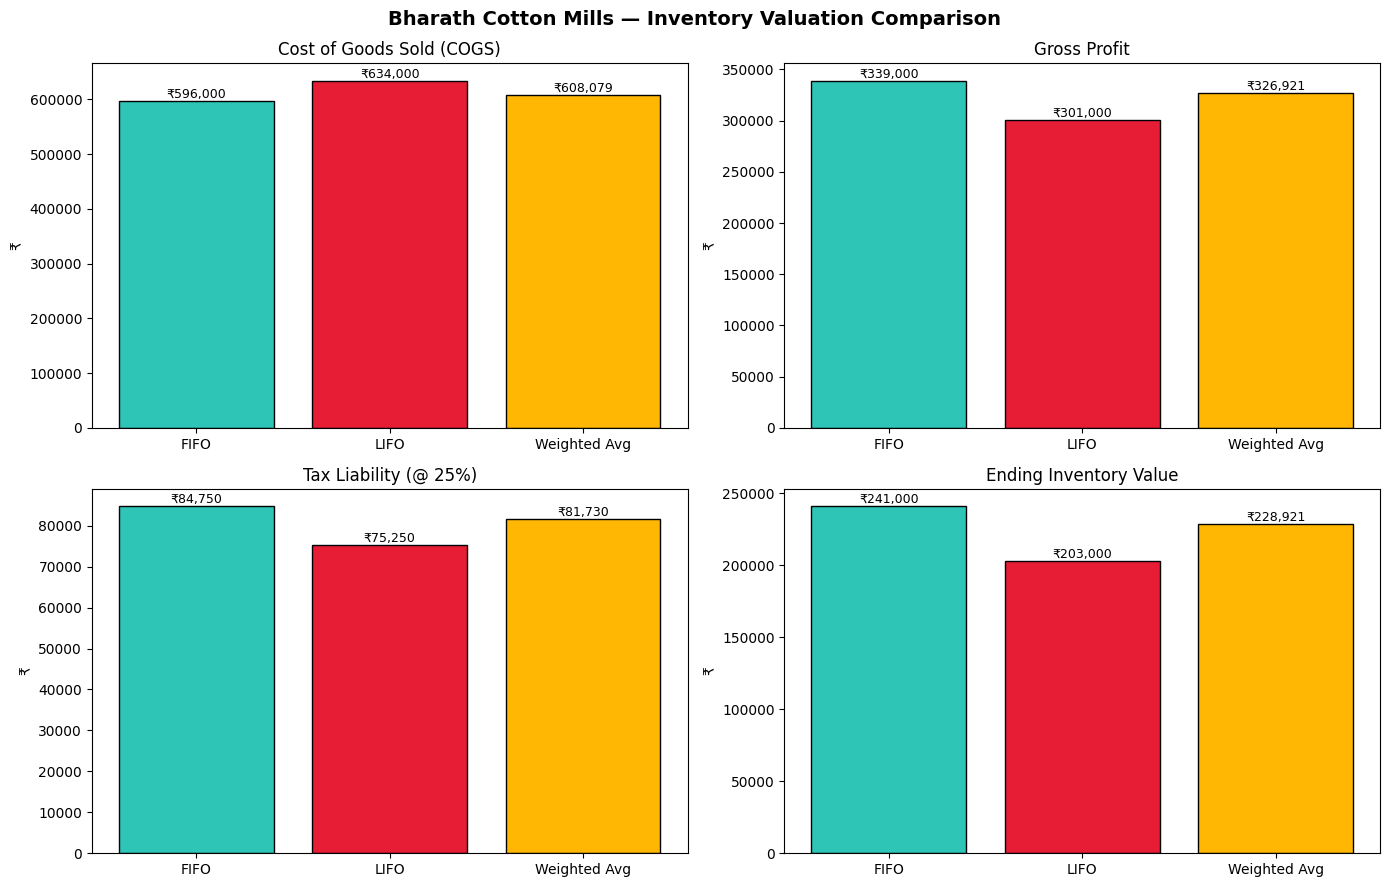

In [7]:
# Visualise the differences
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

colors = ["#2EC4B6", "#E71D36", "#FFB703"]

# COGS
axes[0, 0].bar(methods, cogs, color=colors, edgecolor="black")
axes[0, 0].set_title("Cost of Goods Sold (COGS)")
axes[0, 0].set_ylabel("₹")
for i, v in enumerate(cogs):
    axes[0, 0].text(i, v, f"₹{v:,.0f}", ha="center", va="bottom", fontsize=9)

# Gross profit
gp = [revenue - c for c in cogs]
axes[0, 1].bar(methods, gp, color=colors, edgecolor="black")
axes[0, 1].set_title("Gross Profit")
axes[0, 1].set_ylabel("₹")
for i, v in enumerate(gp):
    axes[0, 1].text(i, v, f"₹{v:,.0f}", ha="center", va="bottom", fontsize=9)

# Tax
tax = [(revenue - c) * TAX_RATE for c in cogs]
axes[1, 0].bar(methods, tax, color=colors, edgecolor="black")
axes[1, 0].set_title("Tax Liability (@ 25%)")
axes[1, 0].set_ylabel("₹")
for i, v in enumerate(tax):
    axes[1, 0].text(i, v, f"₹{v:,.0f}", ha="center", va="bottom", fontsize=9)

# Ending inventory
axes[1, 1].bar(methods, end_inv, color=colors, edgecolor="black")
axes[1, 1].set_title("Ending Inventory Value")
axes[1, 1].set_ylabel("₹")
for i, v in enumerate(end_inv):
    axes[1, 1].text(i, v, f"₹{v:,.0f}", ha="center", va="bottom", fontsize=9)

fig.suptitle("Bharath Cotton Mills — Inventory Valuation Comparison",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

**📝 Finding:** In a **rising-price environment** (which our Q1 transactions reflect — purchase prices climbed from ₹320 to ₹410), the predicted pattern holds:

- **FIFO** produces the **lowest COGS** → **highest profit** → **highest tax**
- **LIFO** produces the **highest COGS** → **lowest profit** → **lowest tax**
- **Weighted Average** sits cleanly in the middle

The same physical 1,000 units sold can produce noticeably different reported profit purely because of the cost-flow assumption.

## 🔹 Recommendation

### Statutory constraint first
Under **Ind AS 2 / AS 2**, LIFO is **not permitted** for financial reporting in India. The choice is therefore between **FIFO** and **Weighted Average**.

### Decision criteria
| Criterion | FIFO | Weighted Avg |
|-----------|:----:|:------------:|
| Easier to explain to non-accountants | ✅ | ❌ |
| Closer to physical flow of goods | ✅ | ⚠️ |
| Smoother profit reporting in volatile prices | ❌ | ✅ |
| Lower current-year tax (rising prices) | ❌ | ✅ |
| Lower closing-inventory value (rising prices) | ❌ | ✅ |

### Verdict — **switch to Weighted Average**

**Reasoning:**
1. With raw cotton prices rising, FIFO inflates this year's profit by reporting it at older (lower) costs — the company pays more tax now, on profit it hasn't actually banked from current production.
2. Weighted Average matches today's cost against today's revenue more faithfully.
3. It is fully compliant with Ind AS 2, so no statutory issue.

A formal accounting policy change requires:
- Audit committee approval
- Disclosure as a change in accounting policy in the next financial statements
- Restatement of comparatives (if material)

---

## ✏️ Practice extensions

- Run the same analysis on a **falling-price** scenario and watch the FIFO/LIFO ranking flip
- Add a **second SKU** and aggregate the company-level totals
- Implement **periodic** weighted-average (one rate for the whole period) vs **perpetual** (the version above) and compare
- Add a **physical stock count** at period end and compute the inventory shrinkage adjustment